In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.optimize as scop
import csv

from scipy.optimize import curve_fit

#LOADING FUNCTION
def load_magnetisation_data(file_location, 
                            cgs_or_si="cgs", 
                            temp_range=(0, 300)):
    """
    Load, sanitise, and optionally convert magnetisation data 
    from a PPMS datafile (Quantum Design format).

    Parameters
    ----------
    file_location : str
        Directory where the data file is stored.
    cgs_or_si : str, default "cgs"
        Choose "cgs" to keep raw PPMS units or "si" for SI conversion.
    temp_range : tuple, default (0, 300)
        Lower and upper bounds for temperature filtering (K).

    Returns
    -------
    df : pd.DataFrame
        Sanitised dataframe in chosen units and restricted to the temperature range.
    headers_line : int
        Index where headers started in the original file.
    """
    FILEANDPATH = file_location

    # Find where headers start (due to PPMS metadata junk at top of file)
    index_of_headers = 0
    for i in range(100):
        try:
            _ = pd.read_csv(FILEANDPATH, sep=",", skiprows=i, encoding="unicode_escape")
            index_of_headers = i + 1  # need +1 for correct parsing
            break
        except Exception:
            continue

    # Load dataframe properly
    df_raw = pd.read_csv(FILEANDPATH, sep=",", skiprows=index_of_headers, encoding="unicode_escape")

    # Drop columns with all NaNs
    df_clean = df_raw.dropna(axis=1, how="all")

    # Convert to SI if requested
    if cgs_or_si.lower() == "cgs":
        df_final = df_clean.copy()
    elif cgs_or_si.lower() == "si":
        df_final = df_clean.copy()
        df_final["Magnetic Field (Oe)"] *= 0.0001
        df_final["Moment (emu)"] *= 1e-3
        df_final.rename(columns={
            "Magnetic Field (Oe)": "Magnetic Field (T)",
            "Moment (emu)": "Moment (Am^2)"
        }, inplace=True)
    else:
        raise ValueError("cgs_or_si must be either 'cgs' or 'si'")

    # Apply temperature range filter
    lower_temp, higher_temp = temp_range
    df_final = df_final[(df_final["Temperature (K)"] >= lower_temp) & 
                        (df_final["Temperature (K)"] <= higher_temp)]

    print(f"Headers found at line {index_of_headers}")
    #print(f"Remaining Column Headers: {df_final.columns}")

    return df_final, index_of_headers

#SAVE PLOT FUNCTION
import os
import matplotlib.pyplot as plt

import os
import matplotlib.pyplot as plt

def save_next_plot(folder, prefix="graph", ext="png", fig=None):
    """
    Save the current matplotlib figure into 'folder' with auto-increment filename.
    
    Parameters
    ----------
    folder : str
        Path to the folder where plots will be saved.
    prefix : str, default 'graph'
        Filename prefix, e.g. 'graph' -> graph_001.png
    ext : str, default 'png'
        File extension, e.g. 'png', 'pdf', 'svg'.
    fig : matplotlib.figure.Figure, optional
        Figure to save. Defaults to current figure.
        
    Returns
    -------
    str
        Full path of the saved file.
    """
    os.makedirs(folder, exist_ok=True)
    
    existing = [f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith("." + ext)]
    numbers = []
    for f in existing:
        try:
            num = int(f.replace(prefix + "_", "").replace("." + ext, ""))
            numbers.append(num)
        except ValueError:
            continue
    
    next_num = max(numbers) + 1 if numbers else 1
    filename = f"{prefix}_{next_num:03d}.{ext}"
    fullpath = os.path.join(folder, filename)
    
    if fig is None:
        fig = plt.gcf()
    
    fig.savefig(fullpath, dpi=300, bbox_inches="tight")
    print(f"Plot saved as: {fullpath}")
    
    return fullpath



#examples of loading data
'''
df_mag1, header_line = load_magnetisation_data(
    file_location=FILEANDPATHMag1,
    cgs_or_si="si",
    temp_range=(2, 100)
)
df_mag2, header_line = load_magnetisation_data(
    file_location=FILEANDPATHMag2,
    cgs_or_si="si",
    temp_range=(2, 100)
)
'''

'\ndf_mag1, header_line = load_magnetisation_data(\n    file_location=FILEANDPATHMag1,\n    cgs_or_si="si",\n    temp_range=(2, 100)\n)\ndf_mag2, header_line = load_magnetisation_data(\n    file_location=FILEANDPATHMag2,\n    cgs_or_si="si",\n    temp_range=(2, 100)\n)\n'

In [31]:
def fit_curie_weiss(T, chi, fit_range=(150, 300), p0=(0.5, 30, 0.0)):
    """
    Fit susceptibility data to a 3-parameter Curie-Weiss model:

        chi(T) = C / (T - theta) + chi0

    Parameters
    ----------
    T : array-like
        Temperature data in K.
    chi : array-like
        Molar susceptibility data in emu mol^-1 Oe^-1.
    fit_range : tuple, optional
        Temperature range (min, max) in K used for the fit.
    p0 : tuple, optional
        Initial guesses for (C, theta, chi0).

    Returns
    -------
    result : dict
        Dictionary containing the fitted parameters, uncertainties,
        fitting data, and fitted curve.

        result["C"]
        result["C_err"]
        result["theta"]
        result["theta_err"]
        result["chi0"]
        result["chi0_err"]
        result["mu_eff"]
        result["mu_eff_err"]
        result["T_fit"]
        result["chi_fit"]
        result["popt"]
        result["pcov"]
    """

    # Convert to numpy arrays
    T = np.asarray(T, dtype=float)
    chi = np.asarray(chi, dtype=float)

    # Select fitting temperature range
    mask = (
        (T >= fit_range[0]) &
        (T <= fit_range[1]) &
        np.isfinite(T) &
        np.isfinite(chi)
    )

    T_fit = T[mask]
    chi_fit = chi[mask]

    if len(T_fit) < 3:
        raise ValueError("Not enough valid data points in the fitting range.")

    # 3-parameter Curie-Weiss model
    def curie_weiss_3param(T, C, theta, chi0):
        return C / (T - theta) + chi0

    # Perform fit
    popt, pcov = curve_fit(
        curie_weiss_3param,
        T_fit,
        chi_fit,
        p0=p0
    )

    C_fit, theta_fit, chi0_fit = popt
    perr = np.sqrt(np.diag(pcov))

    # Parameter uncertainties
    C_err = perr[0]
    theta_err = perr[1]
    chi0_err = perr[2]

    # Effective magnetic moment
    mu_eff = 2.828 * np.sqrt(C_fit)
    mu_eff_err = (
        2.828
        * 0.5
        / np.sqrt(C_fit)
        * C_err
    )

    # Generate smooth fitted curve for plotting later
    T_smooth = np.linspace(
        np.min(T_fit),
        np.max(T_fit),
        500
    )

    chi_smooth = curie_weiss_3param(
        T_smooth,
        *popt
    )

    return {
        "C": C_fit,
        "C_err": C_err,
        "theta": theta_fit,
        "theta_err": theta_err,
        "chi0": chi0_fit,
        "chi0_err": chi0_err,
        "mu_eff": mu_eff,
        "mu_eff_err": mu_eff_err,
        "T_fit": T_fit,
        "chi_fit": chi_fit,
        "T_smooth": T_smooth,
        "chi_smooth": chi_smooth,
        "popt": popt,
        "pcov": pcov,
    }

TB003

Headers found at line 30
Headers found at line 30
===== Curie-Weiss Fit: TB003X3 =====
C       = 0.7668 ± 0.0154 emu K mol^-1 Oe^-1
μ_eff   = 2.476 ± 0.025 μB
θ       = 27.31 ± 1.78 K
χ₀      = -0.000128 ± 0.000042 emu mol^-1 Oe^-1

===== Curie-Weiss Fit: TB003X2 =====
C       = 0.6840 ± 0.0231 emu K mol^-1 Oe^-1
μ_eff   = 2.339 ± 0.040 μB
θ       = 18.83 ± 3.15 K
χ₀      = -0.000369 ± 0.000060 emu mol^-1 Oe^-1


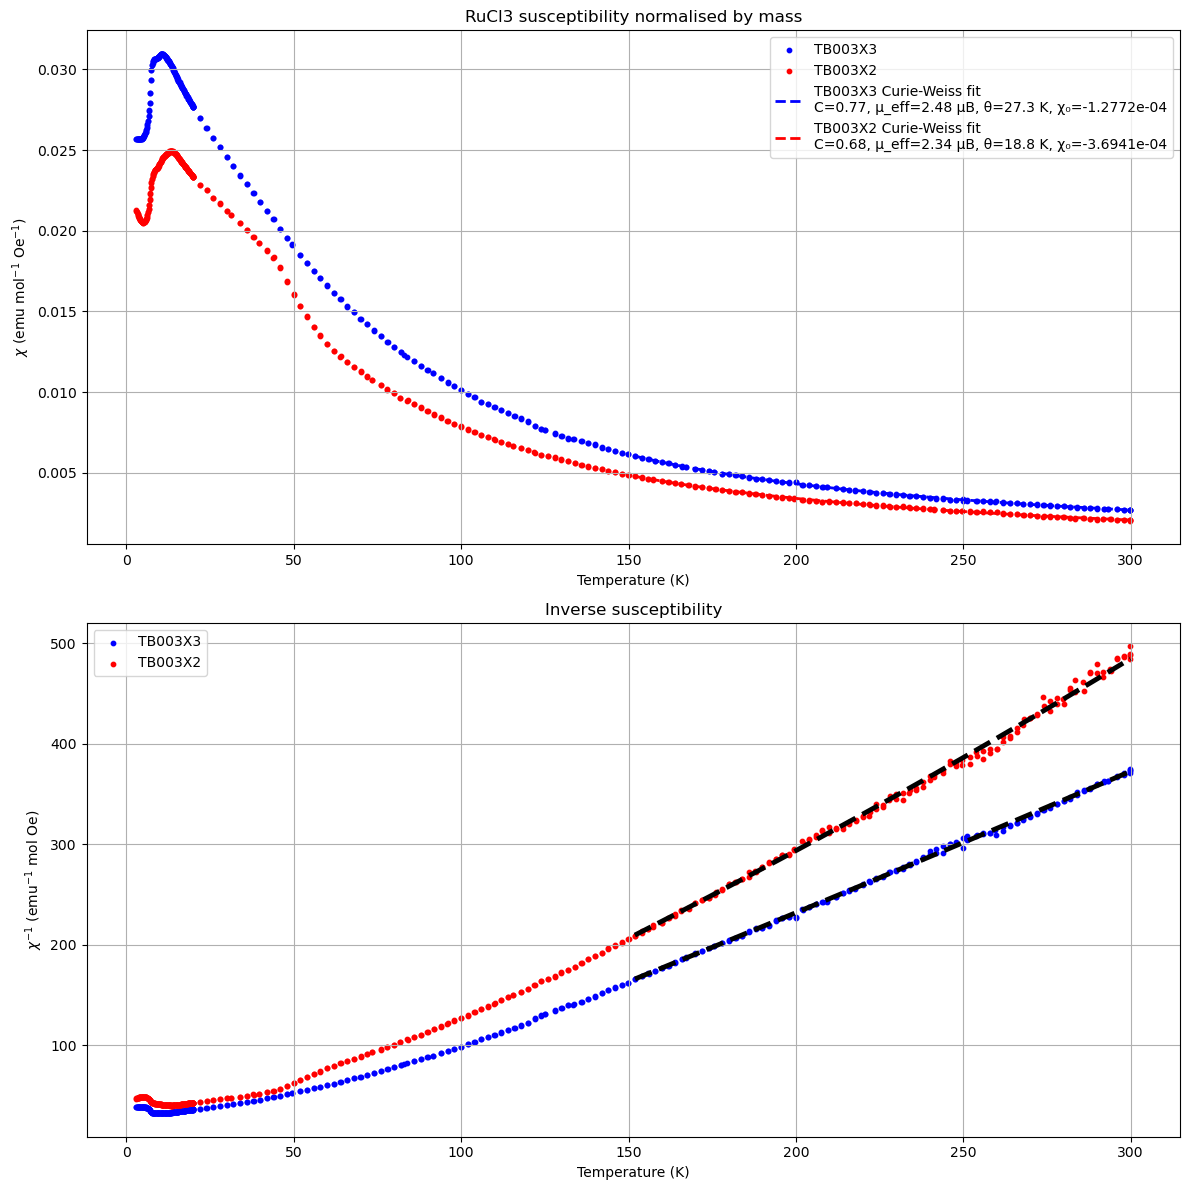

In [32]:
# -----------------------------
# Load your data
# -----------------------------

'''MAGNETISATION DATA'''

filepath = "C:/Users/TXB909/Documents/strain-cell/PPMS_Data_and_Plotting/Data/RuCl3/Data/Magnetisation/"

file1 = "30-03-2026_RUCL3_TB003X3_0.1T_H_PARRA_ABPLANE_FCC__00001.dat"
file2 = "24-03-2026_RUCL3_TB003X2_0.1T_H_PARRA_ABPLANE_FCC_00002.dat"

FILE1 = filepath + file1
FILE2 = filepath + file2


# -----------------------------
# Load datasets
# -----------------------------

df1, header1 = load_magnetisation_data(
    file_location=FILE1,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)

df2, header2 = load_magnetisation_data(
    file_location=FILE2,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)


# -----------------------------
# Clean + sort
# -----------------------------

df1 = df1.replace([np.inf, -np.inf], np.nan)
df1 = df1.dropna(subset=["Temperature (K)", "Moment (emu)"])
df1 = df1.sort_values("Temperature (K)").reset_index(drop=True)

df2 = df2.replace([np.inf, -np.inf], np.nan)
df2 = df2.dropna(subset=["Temperature (K)", "Moment (emu)"])
df2 = df2.sort_values("Temperature (K)").reset_index(drop=True)


# -----------------------------
# Extract variables
# -----------------------------

x1 = df1["Temperature (K)"]
M1 = df1["Moment (emu)"]
H1 = df1["Magnetic Field (Oe)"]

x2 = df2["Temperature (K)"]
M2 = df2["Moment (emu)"]
H2 = df2["Magnetic Field (Oe)"]


# -----------------------------
# Conversion factor
# -----------------------------

mass1 = 0.0041  # g
mass2 = 0.0017  # g

molar_mass = 207.43  # g/mol


chi1 = M1 / H1
y1 = chi1 * molar_mass / mass1
inv_y1 = 1.0 / y1

chi2 = M2 / H2
y2 = chi2 * molar_mass / mass2
inv_y2 = 1.0 / y2


# -----------------------------
# Curie-Weiss fits
# -----------------------------

fit_TB003X3 = fit_curie_weiss(
    T=x1,
    chi=y1,
    fit_range=(150, 300),
    p0=(0.5, 30, 0.0)
)

fit_TB003X2 = fit_curie_weiss(
    T=x2,
    chi=y2,
    fit_range=(150, 300),
    p0=(0.5, 30, 0.0)
)


# -----------------------------
# Print fitted parameters
# -----------------------------

print("===== Curie-Weiss Fit: TB003X3 =====")
print(
    f"C       = {fit_TB003X3['C']:.4f} ± "
    f"{fit_TB003X3['C_err']:.4f} emu K mol^-1 Oe^-1"
)
print(
    f"μ_eff   = {fit_TB003X3['mu_eff']:.3f} ± "
    f"{fit_TB003X3['mu_eff_err']:.3f} μB"
)
print(
    f"θ       = {fit_TB003X3['theta']:.2f} ± "
    f"{fit_TB003X3['theta_err']:.2f} K"
)
print(
    f"χ₀      = {fit_TB003X3['chi0']:.6f} ± "
    f"{fit_TB003X3['chi0_err']:.6f} emu mol^-1 Oe^-1"
)

print()

print("===== Curie-Weiss Fit: TB003X2 =====")
print(
    f"C       = {fit_TB003X2['C']:.4f} ± "
    f"{fit_TB003X2['C_err']:.4f} emu K mol^-1 Oe^-1"
)
print(
    f"μ_eff   = {fit_TB003X2['mu_eff']:.3f} ± "
    f"{fit_TB003X2['mu_eff_err']:.3f} μB"
)
print(
    f"θ       = {fit_TB003X2['theta']:.2f} ± "
    f"{fit_TB003X2['theta_err']:.2f} K"
)
print(
    f"χ₀      = {fit_TB003X2['chi0']:.6f} ± "
    f"{fit_TB003X2['chi0_err']:.6f} emu mol^-1 Oe^-1"
)


# -----------------------------
# Plot χ(T) with both fits
# -----------------------------

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))


# --- χ(T)

ax1.scatter(
    x1,
    y1,
    s=10,
    color='b',
    label="TB003X3"
)

ax1.scatter(
    x2,
    y2,
    s=10,
    color='r',
    label="TB003X2"
)


# TB003X3 Curie-Weiss fit
ax1.plot(
    fit_TB003X3["T_smooth"],
    fit_TB003X3["chi_smooth"],
    'b--',
    linewidth=2,
    label=(
        f"TB003X3 Curie-Weiss fit\n"
        f"C={fit_TB003X3['C']:.2f}, "
        f"μ_eff={fit_TB003X3['mu_eff']:.2f} μB, "
        f"θ={fit_TB003X3['theta']:.1f} K, "
        f"χ₀={fit_TB003X3['chi0']:.4e}"
    )
)


# TB003X2 Curie-Weiss fit
ax1.plot(
    fit_TB003X2["T_smooth"],
    fit_TB003X2["chi_smooth"],
    'r--',
    linewidth=2,
    label=(
        f"TB003X2 Curie-Weiss fit\n"
        f"C={fit_TB003X2['C']:.2f}, "
        f"μ_eff={fit_TB003X2['mu_eff']:.2f} μB, "
        f"θ={fit_TB003X2['theta']:.1f} K, "
        f"χ₀={fit_TB003X2['chi0']:.4e}"
    )
)


ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel(r"$\chi$ (emu mol$^{-1}$ Oe$^{-1}$)")
ax1.set_title("RuCl3 susceptibility normalised by mass")
ax1.grid(True)
ax1.legend()


# -----------------------------
# Plot χ⁻¹(T)
# -----------------------------

ax2.scatter(
    x1,
    inv_y1,
    s=10,
    color='b',
    label="TB003X3"
)

ax2.scatter(
    x2,
    inv_y2,
    s=10,
    color='r',
    label="TB003X2"
)


# Inverse TB003X3 fit
inv_fit_TB003X3 = 1.0 / fit_TB003X3["chi_smooth"]

ax2.plot(
    fit_TB003X3["T_smooth"],
    inv_fit_TB003X3,
    'k--',
    linewidth=3.5
)


# Inverse TB003X2 fit
inv_fit_TB003X2 = 1.0 / fit_TB003X2["chi_smooth"]

ax2.plot(
    fit_TB003X2["T_smooth"],
    inv_fit_TB003X2,
    'k--',
    linewidth=3.5
)


ax2.set_xlabel("Temperature (K)")
ax2.set_ylabel(r"$\chi^{-1}$ (emu$^{-1}$ mol Oe)")
ax2.set_title("Inverse susceptibility")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

TB003 Zoom

Headers found at line 30
Headers found at line 30
===== Curie-Weiss Fit: TB003X3 =====
C       = 0.7668 ± 0.0154 emu K mol^-1 Oe^-1
μ_eff   = 2.476 ± 0.025 μB
θ       = 27.31 ± 1.78 K
χ₀      = -0.000128 ± 0.000042 emu mol^-1 Oe^-1

===== Curie-Weiss Fit: TB003X2 =====
C       = 0.6840 ± 0.0231 emu K mol^-1 Oe^-1
μ_eff   = 2.339 ± 0.040 μB
θ       = 18.83 ± 3.15 K
χ₀      = -0.000369 ± 0.000060 emu mol^-1 Oe^-1


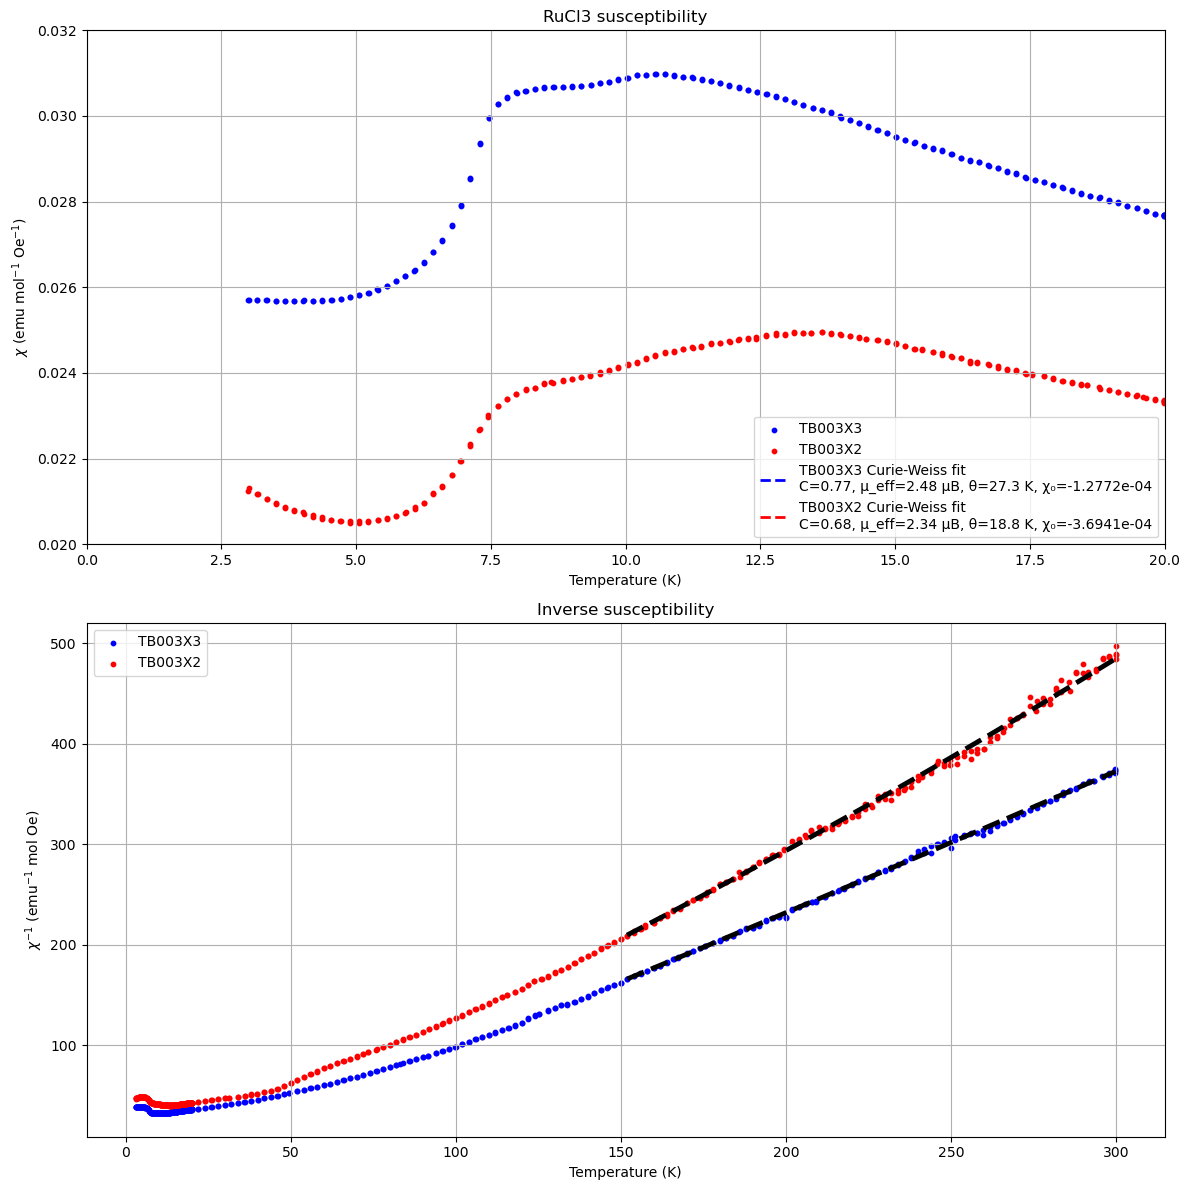

In [36]:
# -----------------------------
# Load your data
# -----------------------------

'''MAGNETISATION DATA'''

filepath = "C:/Users/TXB909/Documents/strain-cell/PPMS_Data_and_Plotting/Data/RuCl3/Data/Magnetisation/"

file1 = "30-03-2026_RUCL3_TB003X3_0.1T_H_PARRA_ABPLANE_FCC__00001.dat"
file2 = "24-03-2026_RUCL3_TB003X2_0.1T_H_PARRA_ABPLANE_FCC_00002.dat"

FILE1 = filepath + file1
FILE2 = filepath + file2


# -----------------------------
# Load datasets
# -----------------------------

df1, header1 = load_magnetisation_data(
    file_location=FILE1,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)

df2, header2 = load_magnetisation_data(
    file_location=FILE2,
    cgs_or_si="cgs",
    temp_range=(2, 300)
)


# -----------------------------
# Clean + sort
# -----------------------------

df1 = df1.replace([np.inf, -np.inf], np.nan)
df1 = df1.dropna(subset=["Temperature (K)", "Moment (emu)"])
df1 = df1.sort_values("Temperature (K)").reset_index(drop=True)

df2 = df2.replace([np.inf, -np.inf], np.nan)
df2 = df2.dropna(subset=["Temperature (K)", "Moment (emu)"])
df2 = df2.sort_values("Temperature (K)").reset_index(drop=True)


# -----------------------------
# Extract variables
# -----------------------------

x1 = df1["Temperature (K)"]
M1 = df1["Moment (emu)"]
H1 = df1["Magnetic Field (Oe)"]

x2 = df2["Temperature (K)"]
M2 = df2["Moment (emu)"]
H2 = df2["Magnetic Field (Oe)"]


# -----------------------------
# Conversion factor
# -----------------------------

mass1 = 0.0041  # g
mass2 = 0.0017  # g

molar_mass = 207.43  # g/mol


chi1 = M1 / H1
y1 = chi1 * molar_mass / mass1
inv_y1 = 1.0 / y1

chi2 = M2 / H2
y2 = chi2 * molar_mass / mass2
inv_y2 = 1.0 / y2


# -----------------------------
# Curie-Weiss fits
# -----------------------------

fit_TB003X3 = fit_curie_weiss(
    T=x1,
    chi=y1,
    fit_range=(150, 300),
    p0=(0.5, 30, 0.0)
)

fit_TB003X2 = fit_curie_weiss(
    T=x2,
    chi=y2,
    fit_range=(150, 300),
    p0=(0.5, 30, 0.0)
)


# -----------------------------
# Print fitted parameters
# -----------------------------

print("===== Curie-Weiss Fit: TB003X3 =====")
print(
    f"C       = {fit_TB003X3['C']:.4f} ± "
    f"{fit_TB003X3['C_err']:.4f} emu K mol^-1 Oe^-1"
)
print(
    f"μ_eff   = {fit_TB003X3['mu_eff']:.3f} ± "
    f"{fit_TB003X3['mu_eff_err']:.3f} μB"
)
print(
    f"θ       = {fit_TB003X3['theta']:.2f} ± "
    f"{fit_TB003X3['theta_err']:.2f} K"
)
print(
    f"χ₀      = {fit_TB003X3['chi0']:.6f} ± "
    f"{fit_TB003X3['chi0_err']:.6f} emu mol^-1 Oe^-1"
)

print()

print("===== Curie-Weiss Fit: TB003X2 =====")
print(
    f"C       = {fit_TB003X2['C']:.4f} ± "
    f"{fit_TB003X2['C_err']:.4f} emu K mol^-1 Oe^-1"
)
print(
    f"μ_eff   = {fit_TB003X2['mu_eff']:.3f} ± "
    f"{fit_TB003X2['mu_eff_err']:.3f} μB"
)
print(
    f"θ       = {fit_TB003X2['theta']:.2f} ± "
    f"{fit_TB003X2['theta_err']:.2f} K"
)
print(
    f"χ₀      = {fit_TB003X2['chi0']:.6f} ± "
    f"{fit_TB003X2['chi0_err']:.6f} emu mol^-1 Oe^-1"
)


# -----------------------------
# Plot χ(T) with both fits
# -----------------------------

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))


# --- χ(T)

ax1.scatter(
    x1,
    y1,
    s=10,
    color='b',
    label="TB003X3"
)

ax1.scatter(
    x2,
    y2,
    s=10,
    color='r',
    label="TB003X2"
)


# TB003X3 Curie-Weiss fit
ax1.plot(
    fit_TB003X3["T_smooth"],
    fit_TB003X3["chi_smooth"],
    'b--',
    linewidth=2,
    label=(
        f"TB003X3 Curie-Weiss fit\n"
        f"C={fit_TB003X3['C']:.2f}, "
        f"μ_eff={fit_TB003X3['mu_eff']:.2f} μB, "
        f"θ={fit_TB003X3['theta']:.1f} K, "
        f"χ₀={fit_TB003X3['chi0']:.4e}"
    )
)


# TB003X2 Curie-Weiss fit
ax1.plot(
    fit_TB003X2["T_smooth"],
    fit_TB003X2["chi_smooth"],
    'r--',
    linewidth=2,
    label=(
        f"TB003X2 Curie-Weiss fit\n"
        f"C={fit_TB003X2['C']:.2f}, "
        f"μ_eff={fit_TB003X2['mu_eff']:.2f} μB, "
        f"θ={fit_TB003X2['theta']:.1f} K, "
        f"χ₀={fit_TB003X2['chi0']:.4e}"
    )
)


ax1.set_xlabel("Temperature (K)")
ax1.set_ylabel(r"$\chi$ (emu mol$^{-1}$ Oe$^{-1}$)")
ax1.set_title("RuCl3 susceptibility")
ax1.set_ylim(0.02, 0.032)
ax1.set_xlim(0, 20)
ax1.grid(True)
ax1.legend()


# -----------------------------
# Plot χ⁻¹(T)
# -----------------------------

ax2.scatter(
    x1,
    inv_y1,
    s=10,
    color='b',
    label="TB003X3"
)

ax2.scatter(
    x2,
    inv_y2,
    s=10,
    color='r',
    label="TB003X2"
)


# Inverse TB003X3 fit
inv_fit_TB003X3 = 1.0 / fit_TB003X3["chi_smooth"]

ax2.plot(
    fit_TB003X3["T_smooth"],
    inv_fit_TB003X3,
    'k--',
    linewidth=3.5
)


# Inverse TB003X2 fit
inv_fit_TB003X2 = 1.0 / fit_TB003X2["chi_smooth"]

ax2.plot(
    fit_TB003X2["T_smooth"],
    inv_fit_TB003X2,
    'k--',
    linewidth=3.5
)


ax2.set_xlabel("Temperature (K)")
ax2.set_ylabel(r"$\chi^{-1}$ (emu$^{-1}$ mol Oe)")
ax2.set_title("Inverse susceptibility")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

TB002
